# Grant Data False Positive Classifier
**SoOI 2026 — Open Infrastructure Grant Matching**

This notebook tests a few-shot LLM approach to identify false positives from grant search term matching.

**Workflow:**
1. Load annotated test set from Google Drive
2. Define few-shot prompt (main iteration surface)
3. Run classification against test set
4. Evaluate: precision/recall/F1 on false positive class
5. Error analysis by OI

**Models:** Use `claude-haiku-4-5-20251001` for iteration (fast/cheap). Switch to `claude-sonnet-4-6` for final run with reasoning.

---

## 1. Setup

In [2]:
# Install dependencies
!pip install anthropic pandas scikit-learn matplotlib seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.5/837.5 kB 17.2 MB/s eta 0:00:00


In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
for item in os.listdir('/content/drive/Shareddrives/IOI Team Drive/Research/Projects_Research/Current_Projects_Research/2026_State_of_OI/02_Research/Grant Funding/False positive classifier'):
    print(item)

false positive test set 2025.csv
Copy of search_results_scrape_and_nsf20241206.gsheet
grant_fp_classifier.ipynb


In [4]:
import anthropic
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, accuracy_score
)
from google.colab import userdata
import time
import json
from IPython.display import display

# API client — key stored in Colab Secrets (key icon in left sidebar)
# Add your key there with the name ANTHROPIC_API_KEY
client = anthropic.Anthropic(api_key=userdata.get('ANTHROPIC_API_KEY'))

print("✓ Setup complete")

✓ Setup complete


## 2. Configuration

Set your file path and model here. Change `MODEL` to `claude-sonnet-4-6` for the final run.

In [26]:
# ── EDIT THESE ──────────────────────────────────────────────────────────────

# Path to your annotated CSV in Google Drive
DATA_PATH = '/content/drive/Shareddrives/IOI Team Drive/Research/Projects_Research/Current_Projects_Research/2026_State_of_OI/02_Research/Grant Funding/False positive classifier/false positive test set 2024_25.csv'

# Model: use haiku for iteration, sonnet for final run
MODEL = 'claude-haiku-4-5-20251001'
# MODEL = 'claude-sonnet-4-6'  # uncomment for final run

# Output reasoning in final run?
OUTPUT_REASONING = False  # set True for final Sonnet run

# Rate limiting: pause between API calls (seconds)
# Haiku is fast; increase to 0.5 if you hit rate limits
API_DELAY = 0.1

# ────────────────────────────────────────────────────────────────────────────
print(f"Model: {MODEL}")
print(f"Reasoning: {OUTPUT_REASONING}")

Model: claude-haiku-4-5-20251001
Reasoning: False


## 3. Load & Validate Data

In [48]:
# Load CSV
# Expected columns: grant_id, grant_title, grant_description, oi_name, label
df_raw = pd.read_csv(DATA_PATH)

# Sanity check
print("=== Data loaded ===")
print(f"Rows: {len(df_raw)}")
print(f"Columns: {df_raw.columns.tolist()}")
print(f"Null descriptions: {df_raw['grant_description'].isna().sum()}")
print(f"Null titles: {df_raw['grant_title'].isna().sum()}")
print(f"Multi-line descriptions: {df_raw['grant_description'].str.contains(chr(10), na=False).sum()}")
print()

# Label distribution (raw)
print("=== Label distribution (raw) ===")
print(df_raw['label'].value_counts(dropna=False))

=== Data loaded ===
Rows: 1779
Columns: ['label', 'grant_id', 'grant_title', 'grant_description', 'oi_name']
Null descriptions: 67
Null titles: 456
Multi-line descriptions: 255

=== Label distribution (raw) ===
label
TRUE     1114
FALSE     556
NaN       107
??          2
Name: count, dtype: int64


In [49]:
# Clean: exclude blanks and ?? labels, normalise TRUE/FALSE to uppercase
df = df_raw.copy()
df['label'] = df['label'].astype(str).str.strip().str.upper()
df = df[df['label'].isin(['TRUE', 'FALSE'])].reset_index(drop=True)

print(f"Rows after excluding blanks/??: {len(df)} (removed {len(df_raw) - len(df)})")
print()
print("=== Final label distribution ===")
counts = df['label'].value_counts()
print(counts)
total = len(df)
print(f"\nClass balance: {counts.get('TRUE', 0)/total:.1%} TRUE / {counts.get('FALSE', 0)/total:.1%} FALSE")
print(f"Baseline accuracy (predict all TRUE): {counts.get('TRUE', 0)/total:.1%}")

Rows after excluding blanks/??: 1670 (removed 109)

=== Final label distribution ===
label
TRUE     1114
FALSE     556
Name: count, dtype: int64

Class balance: 66.7% TRUE / 33.3% FALSE
Baseline accuracy (predict all TRUE): 66.7%


In [50]:
# OI distribution — useful for error analysis later
print("=== OI coverage ===")
oi_counts = df.groupby('oi_name')['label'].value_counts().unstack(fill_value=0)
oi_counts['total'] = oi_counts.sum(axis=1)
oi_counts['fp_rate'] = (oi_counts.get('FALSE', 0) / oi_counts['total']).round(3)

print(f"Total OIs in dataset: {len(oi_counts)}")
print(f"OIs with at least one FALSE: {(oi_counts.get('FALSE', 0) > 0).sum()}")
print()

pd.set_option('display.max_rows', None)
display(oi_counts.sort_values('fp_rate', ascending=False))
pd.reset_option('display.max_rows')

=== OI coverage ===
Total OIs in dataset: 90
OIs with at least one FALSE: 50



label,FALSE,TRUE,total,fp_rate
oi_name,,,,
directory of open access journals (doaj),2,0,2,1.000
conifer,7,0,7,1.000
core,9,0,9,1.000
counter code of practice,6,0,6,1.000
roda (repository of authentic digital records),5,0,5,1.000
mirador,9,0,9,1.000
kotahi,1,0,1,1.000
la referencia,16,0,16,1.000
mycore,1,0,1,1.000


## 4. Few-Shot Prompt

**This is your main iteration surface.** Edit the system prompt and examples, then re-run cells 5 and 6 to evaluate.

Key patterns to cover in examples:
- Generic word use (e.g. "fulcrum" as a common noun)
- Acronym collision with gene names / other domains
- True positives that look ambiguous (grant *uses* OI)
- True positives where the OI is mentioned in passing but is clearly in scope

In [51]:
# ── EDIT THIS CELL WHEN ITERATING ───────────────────────────────────────────

SYSTEM_PROMPT = """You are classifying whether a grant record is a TRUE MATCH or FALSE POSITIVE for a given open infrastructure (OI).

TRUE = the OI is explicitly named as something the project will use,
connect to, deposit into, publish through, promote, or integrate —
even if it is one of several tools named, or a minor part of the project.

This includes:
- Directly funding or sustaining the OI
- Using it as a tool, platform, or repository (depositing data, publishing
  preprints, accessing records, submitting manuscripts, etc.)
- Integrating it as a component of what the project builds
- Disseminating outputs through it (preprints, datasets, code, results)
- Promoting datasets or tools on it alongside other platforms
- Linking to or connecting with it as one of several named identifiers or services

FALSE = the OI is not explicitly named with intent to use, or the term
matched something unrelated:
- The matched word or acronym refers to something else entirely (a gene,
  a common word, a different organisation, a computer science term)
- The OI is cited only as a landscape example of what exists
  ("activities such as X", "providers such as X, Y, and Z") with no
  commitment to use it
- The OI is named only as a comparison or inspiration, not as something
  the project will actually use ("on the model of X", "inspired by X",
  "similar to X")
- The OI name is used as a generic noun ("a dataverse", "a commons")
  rather than referring to the specific named platform
- The grant is about the same topic as the OI but does not explicitly
  name it as something the project will use
- The OI is acknowledged as prior work or community context the project
  builds upon intellectually, without committing to use the platform
  ("builds upon the success of X", "extends the work of X",
  "motivated by X")

Important: topical relevance alone is not sufficient for TRUE. A grant
about persistent identifiers, open science, or data repositories is not
a TRUE match for a specific OI unless that OI is explicitly named with
intent to use it.

Respond with exactly one word: TRUE, FALSE, or UNCERTAIN.
Use UNCERTAIN when the grant mentions the OI but it is genuinely unclear
whether the relationship constitutes active use or merely acknowledgement."""


FEW_SHOT_EXAMPLES = [
    (
        "Fulcrum",
        "4.48 Psychosis: A National Theatre Revival",
        "Delivered with 4 national organisational partners and 4 academic "
        "researchers, 4.48 will grow debate and research, with its fulcrum "
        "a revival of 4.48 PSYCHOSIS delivered alongside an extended "
        "auxiliary event programme.",
        "FALSE"
        # 'fulcrum' is a common noun, not a reference to the OI
    ),
    (
        "ROR",
        "Characterisation of ROR1 and ROR2 receptor tyrosine kinases in "
        "breast cancer progression",
        "ROR1 and ROR2 are receptor tyrosine kinase-like orphan receptors "
        "implicated in oncogenesis. This study investigates their expression "
        "patterns and downstream signalling in triple-negative breast cancer "
        "cell lines.",
        "FALSE"
        # ROR is a gene family acronym here, not the Research Organisation Registry
    ),
    (
        "RRIDs",
        "Collaborative Research: FAIR Facilities and Instruments: Enabling "
        "transparency, reproducibility, and equity through persistent identifiers",
        "This research coordination network will advance the standardization "
        "and adoption of Persistent Identifiers (PIDs) for research facilities "
        "and instruments nationally. PIDs are widely seen as foundational to "
        "open science. While many categories of PIDs have come a long way "
        "(examples: DOIs for publications, ORCIDs for researchers), this "
        "project is focused on advancing PIDs for research facilities and "
        "instruments. This project builds on activities already being "
        "undertaken such as RRIDs (Research Resource Identifiers), and will "
        "convene a series of workshops and stakeholder engagements to better "
        "understand the field and develop principles of design for new PIDs.",
        "FALSE"
        # RRIDs cited as a landscape example of existing activity — grant
        # is about PIDs generally, not using or funding RRIDs specifically.
        # Topical relevance alone is not sufficient.
    ),
    (
        "Dataverse",
        "CC* Data: ImPACT - Infrastructure for Privacy-Assured compuTations",
        "To enable end-to-end data flows, ImPACT builds upon prior investments "
        "and enabling cyberinfrastructure technologies like Dataverse, CyVerse, "
        "and the Open Resource Control Architecture (ORCA) control software.",
        "FALSE"
        # Dataverse is named in a landscape list of enabling technologies —
        # no explicit commitment to use it
    ),
    (
        "Dataverse",
        "PIRE: Deeply Decarbonizing Global Industrial Supply Chains",
        "The outcome of this research will be the development of a novel "
        "global dataverse and the advancement of machine learning approaches "
        "to examine GHG emissions drivers for industrial plants.",
        "FALSE"
        # 'dataverse' used as a generic noun meaning a data collection,
        # not a reference to the Dataverse platform
    ),
    (
        "arXiv",
        "Multimessenger astronomy following neutron star merger GW170817",
        "The merger of neutron stars GW170817 has been the best observed "
        "astronomical event in recorded history. Close to 150 preprints "
        "dedicated to the merger appeared on the arXiv during the two days "
        "after the publication of the LIGO result in October 2017.",
        "TRUE"
        # Researchers actively published preprints on arXiv as part of the work
    ),
    (
        "arXiv",
        "AF: Small: Streaming Complexity of Constraint Satisfaction Problems",
        "Progress from the project will be reported on public domain sites "
        "like the arxiv (www.arxiv.org).",
        "TRUE"
        # Explicit commitment to disseminate outputs via arXiv counts as TRUE
        # even as a minor dissemination mention
    ),
    (
        "Dataverse",
        "Cooperative Congressional Election Study 2016",
        "The data produced by this project will be a 2016 Common Content "
        "dataset and will be available on the CCES Dataverse website.",
        "TRUE"
        # Project data is actively deposited and hosted on Dataverse
    ),
    (
        "Pangeo",
        "Climate Process Team on Ocean Transport and Eddy Energy",
        "Newly generated datasets and parameterizations will be promoted on "
        "many platforms (e.g., Pangeo, GitHub), which can be used by the "
        "whole climate community.",
        "TRUE"
        # Explicitly named with intent to promote outputs there — counts as
        # TRUE even as one of two platforms in a parenthetical
    ),
    (
        "PubPub",
        "Supporting the Knowledge Futures Group community publishing platform",
        "To support the growth of the Knowledge Futures Group's PubPub "
        "community publishing platform, enabling open access publishing "
        "infrastructure for academic communities.",
        "TRUE"
        # Grant directly funds PubPub
    ),
]

# ────────────────────────────────────────────────────────────────────────────
print(f"System prompt: {len(SYSTEM_PROMPT)} chars")
print(f"Few-shot examples: {len(FEW_SHOT_EXAMPLES)}")

System prompt: 2266 chars
Few-shot examples: 10


## 5. Classification

In [52]:
def build_messages(oi_name, grant_title, grant_description, include_reasoning=False):
    """Build the messages array for a single classification call."""

    # Build few-shot turns
    messages = []
    for ex_oi, ex_title, ex_desc, ex_label in FEW_SHOT_EXAMPLES:
        user_content = f"""Infrastructure: {ex_oi}
Grant title: {ex_title}
Grant description: {ex_desc}"""
        messages.append({"role": "user", "content": user_content})
        messages.append({"role": "assistant", "content": ex_label})

    # Add the actual query
    if include_reasoning:
        query_suffix = "\n\nRespond with TRUE or FALSE, then on a new line give a brief reason (1 sentence)."
    else:
        query_suffix = ""

    query = f"""Infrastructure: {oi_name}
Grant title: {grant_title}
Grant description: {grant_description}{query_suffix}"""

    messages.append({"role": "user", "content": query})
    return messages


def classify_grant(row, include_reasoning=False):
    """Call the API for a single row. Returns (predicted_label, reasoning or None, raw_response)."""
    messages = build_messages(
        oi_name=row['oi_name'],
        grant_title=row['grant_title'],
        grant_description=row['grant_description'],
        include_reasoning=include_reasoning
    )

    response = client.messages.create(
        model=MODEL,
        max_tokens=100 if not include_reasoning else 300,
        system=SYSTEM_PROMPT,
        messages=messages
    )

    raw = response.content[0].text.strip()

    # Parse label — first word should be TRUE or FALSE
    first_word = raw.split()[0].upper().rstrip('.')
    if first_word in ('TRUE', 'FALSE'):
        label = first_word
    else:
        label = 'PARSE_ERROR'

    reasoning = None
    if include_reasoning and '\n' in raw:
        reasoning = raw.split('\n', 1)[1].strip()

    return label, reasoning, raw


print("✓ Classification functions defined")

✓ Classification functions defined


In [53]:
# Quick smoke test on 5 rows before running the full set
print("=== Smoke test (5 rows) ===")
for _, row in df.head(5).iterrows():
    label, reasoning, raw = classify_grant(row, include_reasoning=OUTPUT_REASONING)
    print(f"OI: {row['oi_name']} | Actual: {row['label']} | Predicted: {label}")
    print(f"  Title: {row['grant_title'][:80]}...")
    if reasoning:
        print(f"  Reason: {reasoning}")
    print()

=== Smoke test (5 rows) ===
OI: osf (open science framework) | Actual: TRUE | Predicted: TRUE
  Title: Global Flourishing Study: Piloting and Waves 1-5...

OI: counter code of practice | Actual: FALSE | Predicted: FALSE
  Title: Biology, Cosmology, and Theological Ethics...

OI: prereview | Actual: TRUE | Predicted: TRUE
  Title: Shaping the future of science communication...

OI: europe pmc | Actual: TRUE | Predicted: TRUE
  Title: Full text COVID-19 preprints in Europe PMC...

OI: sciety | Actual: TRUE | Predicted: TRUE
  Title: Shaping the future of science communication...



In [54]:
# Run classification on full test set
# This will take a few minutes for 1200+ rows on Haiku

predictions = []
reasonings = []
errors = []

print(f"Classifying {len(df)} grants with {MODEL}...")
start_time = time.time()

for i, row in df.iterrows():
    try:
        label, reasoning, raw = classify_grant(row, include_reasoning=OUTPUT_REASONING)
        predictions.append(label)
        reasonings.append(reasoning)
        if label == 'PARSE_ERROR':
            errors.append({'index': i, 'raw': raw})
    except Exception as e:
        predictions.append('API_ERROR')
        reasonings.append(None)
        errors.append({'index': i, 'error': str(e)})

    time.sleep(API_DELAY)

    # Progress every 50 rows
    if (i + 1) % 50 == 0:
        elapsed = time.time() - start_time
        print(f"  {i+1}/{len(df)} rows — {elapsed:.0f}s elapsed")

elapsed = time.time() - start_time
df['predicted'] = predictions
df['reasoning'] = reasonings

print(f"\n✓ Done — {len(df)} rows in {elapsed:.0f}s")
if errors:
    print(f"⚠ {len(errors)} errors — see `errors` variable")

# Save progress to Drive immediately after run completes
import datetime
timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M')
checkpoint_path = f'/content/drive/Shareddrives/IOI Team Drive/Research/Projects_Research/Current_Projects_Research/2026_State_of_OI/02_Research/Grant Funding/False positive classifier/checkpoint_{timestamp}.csv'
df.to_csv(checkpoint_path, index=False)
print(f"✓ Saved to: {checkpoint_path}")

Classifying 1670 grants with claude-haiku-4-5-20251001...
  50/1670 rows — 43s elapsed
  100/1670 rows — 130s elapsed
  150/1670 rows — 228s elapsed
  200/1670 rows — 317s elapsed
  250/1670 rows — 442s elapsed
  300/1670 rows — 565s elapsed
  350/1670 rows — 686s elapsed
  400/1670 rows — 810s elapsed
  450/1670 rows — 933s elapsed
  500/1670 rows — 1055s elapsed
  550/1670 rows — 1176s elapsed
  600/1670 rows — 1300s elapsed
  650/1670 rows — 1408s elapsed
  700/1670 rows — 1502s elapsed
  750/1670 rows — 1596s elapsed
  800/1670 rows — 1691s elapsed
  850/1670 rows — 1785s elapsed
  900/1670 rows — 1904s elapsed
  950/1670 rows — 2016s elapsed
  1000/1670 rows — 2159s elapsed
  1050/1670 rows — 2254s elapsed
  1100/1670 rows — 2355s elapsed
  1150/1670 rows — 2452s elapsed
  1200/1670 rows — 2549s elapsed
  1250/1670 rows — 2670s elapsed
  1300/1670 rows — 2815s elapsed
  1350/1670 rows — 2948s elapsed
  1400/1670 rows — 3069s elapsed
  1450/1670 rows — 3195s elapsed
  1500/1670 row

## 6. Evaluation

In [58]:
# ── RELOAD FROM CHECKPOINT ──────────────────────────────────────────────────
# Run this cell instead of the classification loop if you already have results

CHECKPOINT_PATH = '/content/drive/Shareddrives/IOI Team Drive/Research/Projects_Research/Current_Projects_Research/2026_State_of_OI/02_Research/Grant Funding/False positive classifier/checkpoint_20260529_1424.csv'  # update filename

df = pd.read_csv(CHECKPOINT_PATH, dtype={'predicted': str, 'label': str})
predictions = df['predicted'].tolist()
reasonings = df['reasoning'].tolist() if 'reasoning' in df.columns else [None] * len(df)

print(f"✓ Reloaded {len(df)} rows from checkpoint")
print(df['predicted'].value_counts(dropna=False))

✓ Reloaded 1670 rows from checkpoint
predicted
TRUE           1112
FALSE           513
PARSE_ERROR      45
Name: count, dtype: int64


In [59]:
# Manual review queue — grants flagged by index for human review
# Add df indices here as you identify them (annotation artefacts, known edge cases, etc.)
MANUAL_REVIEW_INDICES = [
    # e.g. 453, 848  # Quantum Metrology duplicates
]

if MANUAL_REVIEW_INDICES:
    df.loc[df.index.isin(MANUAL_REVIEW_INDICES), 'predicted'] = 'NEEDS_REVIEW'
    print(f"Manually flagged for review: {len(MANUAL_REVIEW_INDICES)} grants")

In [60]:
# Filter to clean predictions only
df_eval = df[df['predicted'].isin(['TRUE', 'FALSE'])].copy()
skipped = len(df) - len(df_eval)
if skipped:
    print(f"⚠ Excluding {skipped} rows with parse/API errors from evaluation")
n_review = (df['predicted'] == 'NEEDS_REVIEW').sum()
n_uncertain = (df['predicted'] == 'UNCERTAIN').sum()
if n_review:
    print(f"ℹ {n_review} grants flagged for manual review — excluded from metrics")
if n_uncertain:
    print(f"ℹ {n_uncertain} grants flagged UNCERTAIN — excluded from metrics, see review queue below")
y_true = df_eval['label']
y_pred = df_eval['predicted']



print("=== Overall metrics ===")
print(f"Accuracy:  {accuracy_score(y_true, y_pred):.3f}")
print(f"Baseline (all TRUE): {(y_true == 'TRUE').mean():.3f}")
print()

print("=== Classification report ===")
print(classification_report(y_true, y_pred, target_names=['FALSE', 'TRUE']))

print("=== FALSE POSITIVE class (the one that matters) ===")
fp_precision = precision_score(y_true, y_pred, pos_label='FALSE')
fp_recall = recall_score(y_true, y_pred, pos_label='FALSE')
fp_f1 = f1_score(y_true, y_pred, pos_label='FALSE')
print(f"Precision: {fp_precision:.3f}  (of grants flagged FALSE, how many actually are)")
print(f"Recall:    {fp_recall:.3f}  (of actual FALSE grants, how many we caught)")
print(f"F1:        {fp_f1:.3f}")

⚠ Excluding 45 rows with parse/API errors from evaluation
=== Overall metrics ===
Accuracy:  0.923
Baseline (all TRUE): 0.670

=== Classification report ===
              precision    recall  f1-score   support

       FALSE       0.90      0.86      0.88       536
        TRUE       0.93      0.95      0.94      1089

    accuracy                           0.92      1625
   macro avg       0.92      0.91      0.91      1625
weighted avg       0.92      0.92      0.92      1625

=== FALSE POSITIVE class (the one that matters) ===
Precision: 0.901  (of grants flagged FALSE, how many actually are)
Recall:    0.862  (of actual FALSE grants, how many we caught)
F1:        0.881


In [61]:
# UNCERTAIN review queue
df_uncertain = df[df['predicted'] == 'UNCERTAIN'].copy()
print(f"=== UNCERTAIN grants requiring manual review: {len(df_uncertain)} ===")

pd.set_option('display.max_colwidth', 120)
display(df_uncertain[['oi_name', 'grant_title', 'grant_description']].reset_index())

=== UNCERTAIN grants requiring manual review: 0 ===


,index,oi_name,grant_title,grant_description


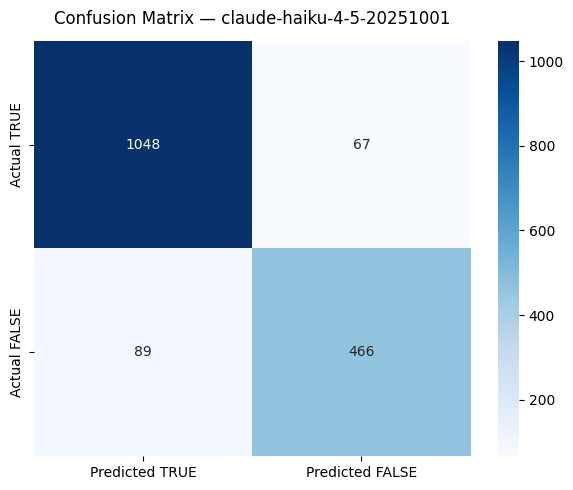

True negatives (correctly caught FALSE): 466
False negatives (missed FALSE positives): 89  ← these slip through to your dataset
False positives (wrongly flagged TRUE as FALSE): 67  ← these get dropped incorrectly


In [35]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_true, y_pred, labels=['TRUE', 'FALSE'])
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted TRUE', 'Predicted FALSE'],
    yticklabels=['Actual TRUE', 'Actual FALSE'],
    ax=ax
)
ax.set_title(f'Confusion Matrix — {MODEL}', pad=12)
plt.tight_layout()
plt.show()

tn, fp_count, fn_count, tp = cm.ravel() if cm.shape == (2,2) else (0,0,0,0)
print(f"True negatives (correctly caught FALSE): {tp}")
print(f"False negatives (missed FALSE positives): {fn_count}  ← these slip through to your dataset")
print(f"False positives (wrongly flagged TRUE as FALSE): {fp_count}  ← these get dropped incorrectly")

## 7. Error Analysis

In [41]:
# Where did the model disagree with annotations?
df_errors = df_eval[df_eval['label'] != df_eval['predicted']].copy()
df_errors['error_type'] = df_errors.apply(
    lambda r: 'Missed FP (model said TRUE, actually FALSE)' if r['label'] == 'FALSE'
    else 'Wrong rejection (model said FALSE, actually TRUE)',
    axis=1
)

print(f"=== Disagreements: {len(df_errors)} / {len(df_eval)} rows ({len(df_errors)/len(df_eval):.1%}) ===")
print(df_errors['error_type'].value_counts())
print()

df_errors_unique = df_errors.drop_duplicates(subset=['grant_title', 'grant_description'])
print(f"Unique error grants: {len(df_errors_unique)} vs total errors: {len(df_errors)}")

=== Disagreements: 156 / 1670 rows (9.3%) ===
error_type
Missed FP (model said TRUE, actually FALSE)          89
Wrong rejection (model said FALSE, actually TRUE)    67
Name: count, dtype: int64

Unique error grants: 97 vs total errors: 156


In [37]:
# Error breakdown by OI — which OIs are hardest?
error_by_oi = df_errors.groupby(['oi_name', 'error_type']).size().unstack(fill_value=0)
error_by_oi['total_errors'] = error_by_oi.sum(axis=1)

# Merge with total counts per OI for context
oi_totals = df_eval.groupby('oi_name').size().rename('total_grants')
error_by_oi = error_by_oi.join(oi_totals)
error_by_oi['error_rate'] = (error_by_oi['total_errors'] / error_by_oi['total_grants']).round(3)

print("=== Errors by OI (sorted by error rate) ===")
display(error_by_oi.sort_values('error_rate', ascending=False))

=== Errors by OI (sorted by error rate) ===


,"Missed FP (model said TRUE, actually FALSE)","Wrong rejection (model said FALSE, actually TRUE)",total_errors,total_grants,error_rate
oi_name,,,,,
adpnet,0,1,1,1,1.000
arches heritage data management platform,0,1,1,1,1.000
opencitations,11,0,11,14,0.786
janeway,0,2,2,3,0.667
sciety,1,0,1,2,0.500
pubpub,1,0,1,2,0.500
metadata encoding and transmission standard (mets),0,1,1,2,0.500
biodiversity information standards (tdwg),0,1,1,2,0.500
public knowledge project,1,2,3,6,0.500


In [47]:
# Inspect individual errors — set OI_FILTER to focus on a specific OI, or None for all
OI_FILTER = 'arxiv'  # e.g. 'Fulcrum' or 'ROR'
ERROR_TYPE_FILTER = None  # e.g. 'Missed FP (model said TRUE, actually FALSE)'

df_inspect = df_errors.copy()
if OI_FILTER:
    df_inspect = df_inspect[df_inspect['oi_name'] == OI_FILTER]
if ERROR_TYPE_FILTER:
    df_inspect = df_inspect[df_inspect['error_type'] == ERROR_TYPE_FILTER]

print(f"{len(df_inspect)} errors for OI: {OI_FILTER}")
print()

# Print each row in full so you don't need to know row numbers
for i, (idx, row) in enumerate(df_inspect.iterrows()):
    print(f"{'='*60}")
    print(f"Error {i+1} of {len(df_inspect)} (df index: {idx})")
    print(f"Type: {row['error_type']}")
    print(f"Actual: {row['label']} | Predicted: {row['predicted']}")
    print(f"\nTITLE: {row['grant_title']}")
    print(f"\nDESCRIPTION:\n{row['grant_description']}")
    if OUTPUT_REASONING and pd.notna(row.get('reasoning')):
        print(f"\nREASONING: {row['reasoning']}")
    print()

12 errors for OI: arxiv

Error 1 of 12 (df index: 440)
Type: Wrong rejection (model said FALSE, actually TRUE)
Actual: TRUE | Predicted: FALSE

TITLE: Investigations in Quantum Metrology and Quantum Entanglement

DESCRIPTION:
Quantum information science (QIS) is the interdisciplinary field that investigates how to use systems obeying the laws of quantum mechanics to perform information-processing tasks.  This project is focused on a set of questions that lie at the intersection of QIS and the science of making high-precision measurements.  This intersection of QIS and measurement science is now called quantum metrology.  The specific questions to be investigated include how best to deploy physical systems, such as atoms and photons and tiny engineered resonators, to make the best possible measurements of such physical quantities as electric and magnetic fields and gravitational fields and how to use the strange property of quantum entanglement associated with interacting systems to imp

In [ ]:
# Full text for a specific error — set ROW_INDEX to the df index of interest
ROW_INDEX = df_errors.index[6]  # change to inspect a different row

row = df_errors.loc[ROW_INDEX]
print(f"OI: {row['oi_name']}")
print(f"Actual label: {row['label']} | Predicted: {row['predicted']}")
print(f"Error type: {row['error_type']}")
print()
print(f"TITLE: {row['grant_title']}")
print()
print(f"DESCRIPTION:\n{row['grant_description']}")
if OUTPUT_REASONING and row.get('reasoning'):
    print(f"\nMODEL REASONING: {row['reasoning']}")

OI: datacite
Actual label: TRUE | Predicted: FALSE
Error type: Wrong rejection (model said FALSE, actually TRUE)

TITLE: nan

DESCRIPTION:
<p>To partially support the csv,conf v7 workshop on open data, open-source software, and open hardware</p>


In [43]:
# Find errors where context is thin
df_errors['title_is_null'] = df_errors['grant_title'].isna() | (df_errors['grant_title'].astype(str).str.lower() == 'nan')
df_errors['desc_word_count'] = df_errors['grant_description'].astype(str).str.split().str.len()

# Show null-title errors sorted by description length
df_thin = df_errors[df_errors['title_is_null']].sort_values('desc_word_count')

print(f"Null-title errors: {len(df_thin)}")
print(f"Of those, description under 20 words: {(df_thin['desc_word_count'] < 20).sum()}")
print(f"Description under 50 words: {(df_thin['desc_word_count'] < 50).sum()}")
print()

pd.set_option('display.max_colwidth', 200)
display(df_thin[['oi_name', 'grant_description', 'desc_word_count', 'error_type']].head(30))

Null-title errors: 44
Of those, description under 20 words: 10
Description under 50 words: 20



,oi_name,grant_description,desc_word_count,error_type
793,datacite,for general operating support,4,"Wrong rejection (model said FALSE, actually TRUE)"
903,datacite,for general operating support,4,"Wrong rejection (model said FALSE, actually TRUE)"
66,wayback machine,<p>To partially support participation in the 2018 Decentralized Web Summit</p>,10,"Wrong rejection (model said FALSE, actually TRUE)"
191,wayback machine,to support the development of a nationwide network of public library web archives,13,"Wrong rejection (model said FALSE, actually TRUE)"
901,datacite,"<p>To partially support the csv,conf v7 workshop on open data, open-source software, and open hardware</p>",15,"Wrong rejection (model said FALSE, actually TRUE)"
64,datacite,"<p>To partially support the csv,conf v7 workshop on open data, open-source software, and open hardware</p>",15,"Wrong rejection (model said FALSE, actually TRUE)"
188,creative commons licenses,"to support an empirical study and analysis of the distinction between ""commercial"" and ""noncommercial"" in Creative Commons licenses",18,"Wrong rejection (model said FALSE, actually TRUE)"
889,creative commons licenses,"to support an empirical study and analysis of the distinction between ""commercial"" and ""noncommercial"" in Creative Commons licenses",18,"Wrong rejection (model said FALSE, actually TRUE)"
175,wayback machine,"to support a final phase of Community Webs, a cohort-based professional training program in web archiving for public libraries",19,"Wrong rejection (model said FALSE, actually TRUE)"
782,sci-kit learn,to maintain and improve scikit image and napari and continue community-building for the benefit of the bioimaging software ecosystem,19,"Wrong rejection (model said FALSE, actually TRUE)"


## 8. Save Results

In [ ]:
# Save full results back to Drive for team review
import datetime
timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M')
model_short = MODEL.split('-')[1]  # 'haiku' or 'sonnet'

output_path = f'/content/drive/MyDrive/sooi-grant-data/results_{model_short}_{timestamp}.csv'

save_cols = ['grant_id', 'oi_name', 'grant_title',
             'grant_description', 'label', 'predicted']
if OUTPUT_REASONING:
    save_cols.append('reasoning')

df_eval[save_cols].to_csv(output_path, index=False)
print(f"✓ Results saved to: {output_path}")
print(f"  {len(df_eval)} rows | Model: {MODEL}")
print(f"  FALSE recall: {fp_recall:.3f} | FALSE precision: {fp_precision:.3f} | F1: {fp_f1:.3f}")

---
## Iteration notes

Use this cell to track what you changed between prompt versions.

| Version | Change | FALSE recall | FALSE precision | F1 |
|---------|--------|-------------|-----------------|----|
| v1 | Baseline few-shot (5 examples) | — | — | — |
| v2 | | | | |
| v3 | | | | |
